In [35]:
import pandas as pd

In [36]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

In [37]:
X_train = X_train.iloc[:,1:]
X_test = X_test.iloc[:,1:]
y_train = y_train.iloc[:,1:]
y_test = y_test.iloc[:,1:]

In [38]:
print(X_train.shape,
      y_train.shape,
      X_test.shape,
      y_test.shape)

(1804151, 42) (1804151, 1) (451425, 42) (451425, 1)


In [39]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [40]:
X_train.head()

,term_36,term_60,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,initial_list_status_f,initial_list_status_w,...,total_rec_int_bin,tot_hi_cred_lim_bin,mo_sin_rcnt_rev_tl_op_bin,dti_bin,avg_cur_bal_bin,inq_last_6mths_bin,mths_since_recent_inq_bin,annual_inc_bin,mths_since_recent_bc_bin,month_since_issue_bin
0,0,1,1,0,0,0,1,0,0,1,...,1,2,2,2,3,0,2,1,4,0
1,1,0,1,0,0,0,1,0,0,1,...,1,0,2,2,1,0,2,0,3,2
2,1,0,1,0,0,0,0,1,0,1,...,3,0,0,3,1,0,2,0,0,4
3,0,1,1,0,0,0,1,0,0,1,...,4,0,1,1,1,1,2,1,1,4
4,1,0,0,0,1,0,0,1,0,1,...,3,2,1,3,3,0,2,1,4,4


#### Build a Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('classifier', LogisticRegression(
        class_weight = 'balanced',
        random_state=1,
        max_iter = 500
    ))
])

In [42]:
param_grid = [
    {
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear'],
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    {
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs'],
        'classifier__C': [0.01, 0.1, 1, 10]
    }
]

In [43]:
random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_grid,
    n_iter=8,
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=2
)


In [44]:
# Fit to training data
random_search.fit(X_train, y_train)
# View best parameters
print(f"Best parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")
test_accuracy = random_search.score(X_test, y_test)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=liblinear; total time= 6.0min
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=liblinear; total time= 6.3min
[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=liblinear; total time= 6.7min
[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=liblinear; total time= 6.4min
[CV] END classifier__C=1, classifier__penalty=l1, classifier__solver=liblinear; total time=25.9min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=lbfgs; total time= 3.5min
[CV] END classifier__C=10, classifier__penalty=l1, classifier__solver=liblinear; total time= 7.4min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=lbfgs; total time= 3.4min
[CV] END classifier__C=0.01, classifier__penalty=l2, classifier__solver=lbfgs; total time= 3.4min
[CV] END classifier__C=0.1, classifier__penalty=l

In [52]:
best_model = random_search.best_estimator_
print("Best params:", random_search.best_params_)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

Best params: {'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': 10}


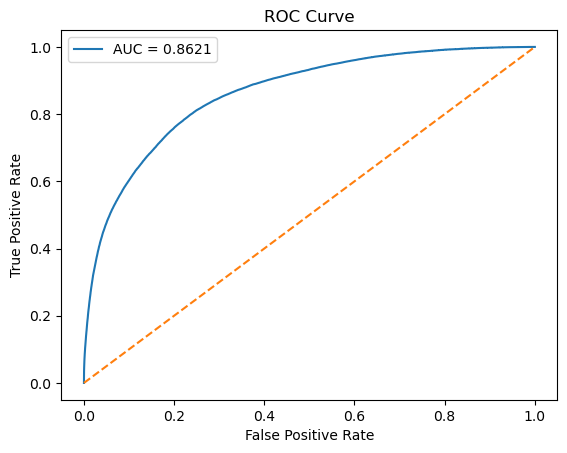

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [54]:
threshold = 0.3
y_pred = (y_pred_proba >= threshold).astype(int)

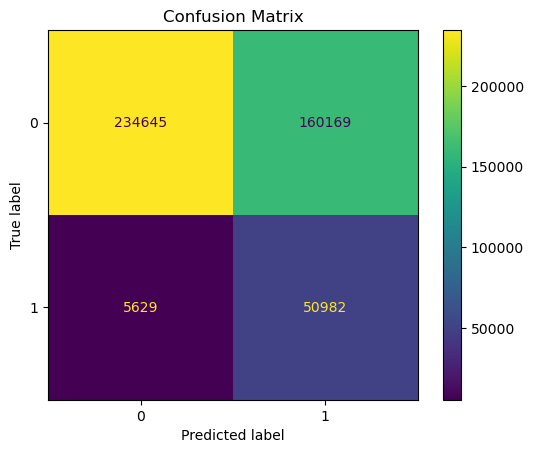

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [56]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.59      0.74    394814
           1       0.24      0.90      0.38     56611

    accuracy                           0.63    451425
   macro avg       0.61      0.75      0.56    451425
weighted avg       0.88      0.63      0.69    451425



In [57]:
import numpy as np
ks = max(tpr - fpr)
print("KS Statistic:", ks)

KS Statistic: 0.5623910273031912


In [51]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0.0, 1.0, 50)

for t in thresholds:
    y_pred = (y_pred_proba >= t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"Threshold {t:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f}")

Threshold 0.00 | Precision: 0.13 | Recall: 1.00
Threshold 0.02 | Precision: 0.13 | Recall: 1.00
Threshold 0.04 | Precision: 0.14 | Recall: 1.00
Threshold 0.06 | Precision: 0.15 | Recall: 0.99
Threshold 0.08 | Precision: 0.15 | Recall: 0.99
Threshold 0.10 | Precision: 0.16 | Recall: 0.98
Threshold 0.12 | Precision: 0.17 | Recall: 0.98
Threshold 0.14 | Precision: 0.18 | Recall: 0.97
Threshold 0.16 | Precision: 0.18 | Recall: 0.96
Threshold 0.18 | Precision: 0.19 | Recall: 0.95
Threshold 0.20 | Precision: 0.20 | Recall: 0.95
Threshold 0.22 | Precision: 0.21 | Recall: 0.94
Threshold 0.24 | Precision: 0.22 | Recall: 0.93
Threshold 0.27 | Precision: 0.23 | Recall: 0.92
Threshold 0.29 | Precision: 0.23 | Recall: 0.91
Threshold 0.31 | Precision: 0.24 | Recall: 0.90
Threshold 0.33 | Precision: 0.25 | Recall: 0.89
Threshold 0.35 | Precision: 0.26 | Recall: 0.88
Threshold 0.37 | Precision: 0.27 | Recall: 0.87
Threshold 0.39 | Precision: 0.28 | Recall: 0.86
Threshold 0.41 | Precision: 0.29 | Recal

/Users/hanhnh1002/miniforge3/envs/pyenv312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [58]:
import numpy as np
import pandas as pd

# Constants for score scaling
PDO = 20  # points to double the odds
base_score = 600
base_odds = 20  # e.g. score 600 corresponds to 20:1 good:bad odds

clf = best_model.named_steps['classifier']
feature_names = X_train.columns
coefs = clf.coef_[0]
intercept = clf.intercept_[0]

factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)

# Score contribution per unit of each feature
feature_points = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'points_per_unit': -coefs * factor
})

feature_points = feature_points.sort_values(by='points_per_unit', key=abs, ascending=False)
print(feature_points)

# Compute total score for test set
X_test_array = X_test.values
scores_test = offset - factor * (intercept + np.dot(X_test_array, coefs))

print('Score range:', scores_test.min(), scores_test.max())
print('Example scores:', scores_test[:10])

# Add scores to a DataFrame
score_df = X_test.copy()
score_df['score'] = scores_test
score_df['y_true'] = y_test
score_df['y_pred_proba'] = y_pred_proba
score_df['y_pred'] = y_pred
score_df.head()

                                feature      coef  points_per_unit
15                      total_pymnt_bin -1.212932        34.997809
41                month_since_issue_bin  1.071115       -30.905836
32                    total_rec_int_bin  0.925981       -26.718155
13        disbursement_method_DirectPay -0.760629        21.947101
5      verification_status_Not Verified -0.578917        16.704002
10         application_type _Individual -0.540270        15.588896
9                 initial_list_status_w -0.414349        11.955582
0                               term_36 -0.409863        11.826154
1                               term_60 -0.398636        11.502192
8                 initial_list_status_f -0.394150        11.372765
2               home_ownership_MORTGAGE -0.339665         9.800650
11          application_type _Joint App -0.268229         7.739450
3                    home_ownership_OWN -0.256175         7.391648
4                   home_ownership_RENT -0.212659         6.13

,term_36,term_60,home_ownership_MORTGAGE,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,initial_list_status_f,initial_list_status_w,...,avg_cur_bal_bin,inq_last_6mths_bin,mths_since_recent_inq_bin,annual_inc_bin,mths_since_recent_bc_bin,month_since_issue_bin,score,y_true,y_pred_proba,y_pred
0,1,0,0,0,1,0,0,1,1,0,...,3,0,2,5,3,4,567.905446,0,0.131997,0
1,0,1,1,0,0,0,1,0,0,1,...,0,0,1,4,3,3,484.756545,0,0.730725,1
2,1,0,0,0,1,1,0,0,1,0,...,1,0,0,0,3,4,550.176682,0,0.219431,0
3,1,0,1,0,0,0,1,0,0,1,...,2,1,1,2,1,1,567.919412,0,0.131941,0
4,1,0,1,0,0,0,0,1,0,1,...,3,0,2,2,4,4,665.186972,0,0.005195,0
